In [90]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter1d

# **Depth=8**
***

In [91]:
fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/y-task-formulations/p(y | y_sparse)/2025-02-01_10-35-40_swinir-baseline/results.csv"
df = pd.read_csv(fp)
df.head()

,global_train_step,global_val_step,epoch,train_loss,val_loss,z
0,0.0,NaN,0,0.016265,NaN,NaN
1,1.0,NaN,0,0.011728,NaN,NaN
2,2.0,NaN,0,0.011238,NaN,NaN
3,3.0,NaN,0,0.009904,NaN,NaN
4,4.0,NaN,0,0.012490,NaN,NaN


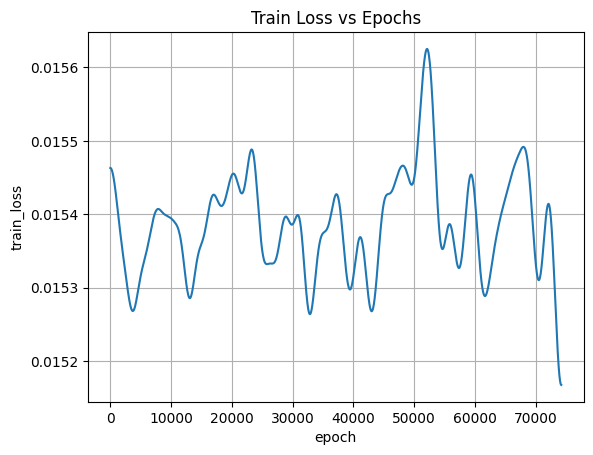

In [92]:
SIGMA = 1000

_df = df[df["global_train_step"].notna()]
train_steps = _df["global_train_step"]
train_losses = _df["train_loss"]
train_losses_smoothed = gaussian_filter1d(train_losses, sigma=SIGMA)

# plt.plot(train_steps, train_losses)
plt.plot(train_steps, train_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("train_loss")
plt.title("Train Loss vs Epochs")
plt.grid()
plt.show()

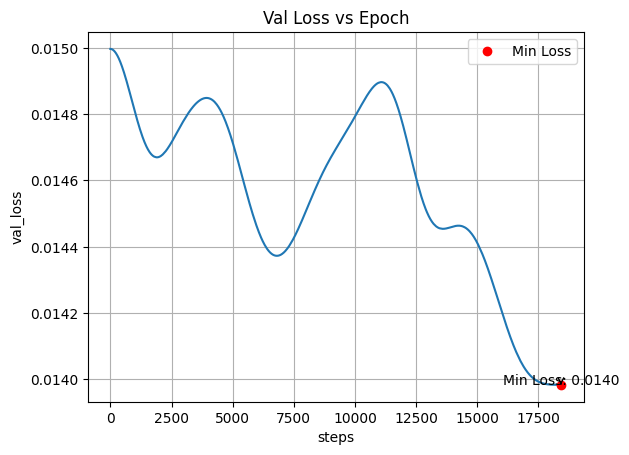

In [93]:
_df = df[df["global_val_step"].notna()]

val_steps = _df["global_val_step"].values
val_losses = _df["val_loss"].values
val_losses_smoothed = gaussian_filter1d(val_losses, sigma=SIGMA)

# find lowest point in the smoothed losses
min_index = np.argmin(val_losses_smoothed)
lowest_val_epoch = val_steps[min_index]
lowest_val_loss = val_losses_smoothed[min_index]

# plot smoothed loss
plt.plot(val_steps, val_losses_smoothed)
plt.xlabel("steps")
plt.ylabel("val_loss")
plt.title("Val Loss vs Epoch")
plt.grid(True)

# plot red dot at the lowest loss point
plt.plot(lowest_val_epoch, lowest_val_loss, 'ro', label='Min Loss')
 
# annotate lowest loss value on the figure
plt.annotate(f'Min Loss: {lowest_val_loss:.4f}',
             xy=(lowest_val_epoch, lowest_val_loss), 
             xytext=(lowest_val_epoch, lowest_val_loss), 
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             ha='center')

plt.legend()
plt.show()

In [94]:
f"{(np.mean(train_losses[-500: ]))*1:.5f}%", f"{(np.mean(val_losses[-500: ]) * 100):.5f}%"

('0.01499%', '1.38915%')

# **Depth=32**
***

In [95]:
fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/y-task-formulations/p(y | y_sparse)/6a. train-runs/2025-02-01_13-34-55_swinir-depth=32/results.csv"
df = pd.read_csv(fp)
df.head()

,global_train_step,global_val_step,epoch,train_loss,val_loss,z
0,0.0,NaN,0,0.009898,NaN,NaN
1,1.0,NaN,0,0.019462,NaN,NaN
2,2.0,NaN,0,0.014571,NaN,NaN
3,3.0,NaN,0,0.009888,NaN,NaN
4,4.0,NaN,0,0.013181,NaN,NaN


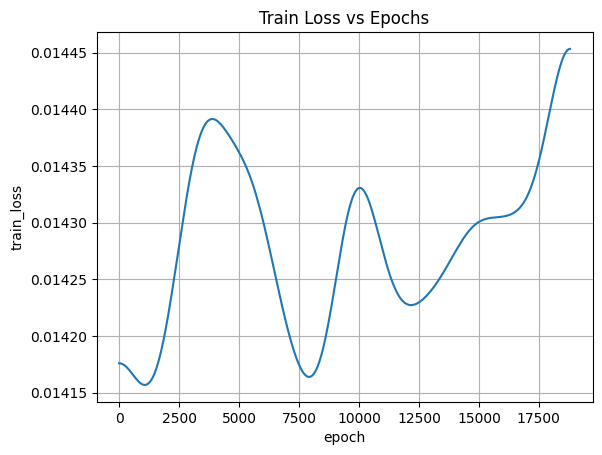

In [96]:
SIGMA = 1000

_df = df[df["global_train_step"].notna()]
train_steps = _df["global_train_step"]
train_losses = _df["train_loss"]
train_losses_smoothed = gaussian_filter1d(train_losses, sigma=SIGMA)

# plt.plot(train_steps, train_losses)
plt.plot(train_steps, train_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("train_loss")
plt.title("Train Loss vs Epochs")
plt.grid()
plt.show()

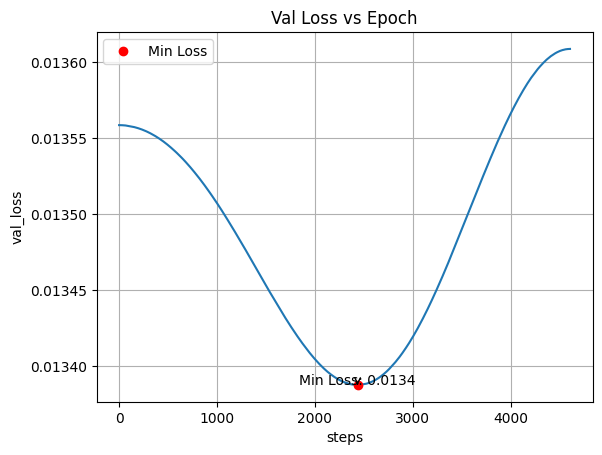

In [97]:
_df = df[df["global_val_step"].notna()]

val_steps = _df["global_val_step"].values
val_losses = _df["val_loss"].values
val_losses_smoothed = gaussian_filter1d(val_losses, sigma=SIGMA)

# find lowest point in the smoothed losses
min_index = np.argmin(val_losses_smoothed)
lowest_val_epoch = val_steps[min_index]
lowest_val_loss = val_losses_smoothed[min_index]

# plot smoothed loss
plt.plot(val_steps, val_losses_smoothed)
plt.xlabel("steps")
plt.ylabel("val_loss")
plt.title("Val Loss vs Epoch")
plt.grid(True)

# plot red dot at the lowest loss point
plt.plot(lowest_val_epoch, lowest_val_loss, 'ro', label='Min Loss')
 
# annotate lowest loss value on the figure
plt.annotate(f'Min Loss: {lowest_val_loss:.4f}',
             xy=(lowest_val_epoch, lowest_val_loss), 
             xytext=(lowest_val_epoch, lowest_val_loss), 
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             ha='center')

plt.legend()
plt.show()

# **Surrogate Model Training**
***

In [98]:
import pandas as pd
from matplotlib import pyplot as plt

fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/y-task-formulations/p(y | y_sparse)/6c.surrogate-train-runs/2025-02-01_16-49-00_surrogate-depth=8/results.csv"
df = pd.read_csv(fp)
df.head()

,global_train_step,global_val_step,epoch,train_loss,val_loss,z,train_denoising_loss,val_denoising_loss,train_surrogate_loss,val_surrogate_loss
0,0.0,NaN,0,NaN,NaN,NaN,0.065032,NaN,0.672506,NaN
1,1.0,NaN,0,NaN,NaN,NaN,0.024330,NaN,0.256638,NaN
2,2.0,NaN,0,NaN,NaN,NaN,2.723874,NaN,2.620449,NaN
3,3.0,NaN,0,NaN,NaN,NaN,2.468976,NaN,2.222497,NaN
4,4.0,NaN,0,NaN,NaN,NaN,1.246420,NaN,1.051064,NaN


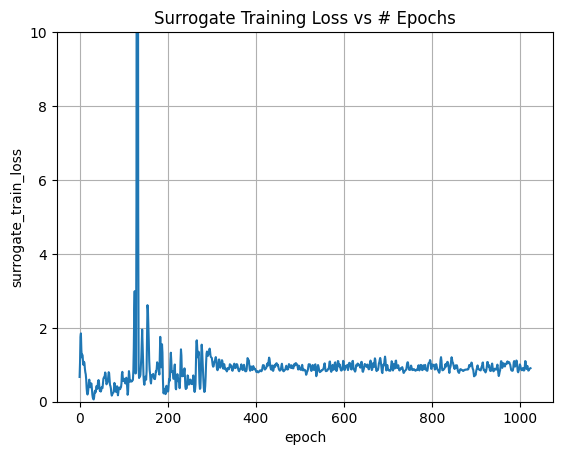

In [99]:
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter1d

SIGMA = 1

_df = df[df["global_train_step"].notna()]
train_steps = _df["global_train_step"]
train_losses = _df["train_surrogate_loss"]
train_losses_smoothed = gaussian_filter1d(train_losses, sigma=SIGMA)

plt.plot(train_steps, train_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("surrogate_train_loss")

plt.ylim(0, 10)

plt.title("Surrogate Training Loss vs # Epochs")
plt.grid()
plt.show()

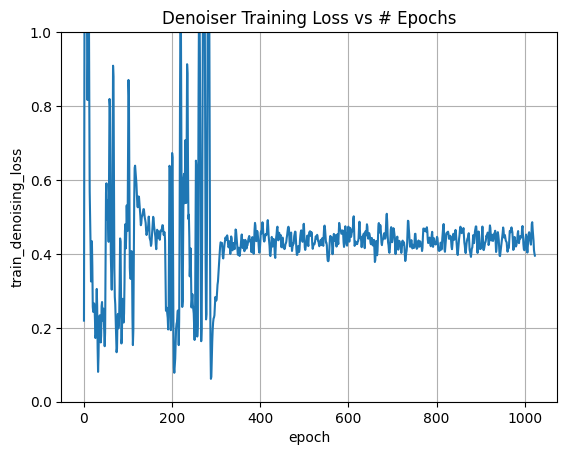

In [100]:
SIGMA = 1

_df = df[df["global_train_step"].notna()]
train_steps = _df["global_train_step"]
train_losses = _df["train_denoising_loss"]
train_losses_smoothed = gaussian_filter1d(train_losses, sigma=SIGMA)

plt.plot(train_steps, train_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("train_denoising_loss")
plt.ylim(0, 1)

plt.title("Denoiser Training Loss vs # Epochs")
plt.grid()
plt.show()